# Kernel Mechanism Walkthrough

This notebook starts **exactly where** [inverse_problem_walkthrough.ipynb](./inverse_problem_walkthrough.ipynb) ends.

That notebook finishes by producing three toy slice graphs and their WL feature matrix:

- `shared_signal`
- `same_circuit`
- `other_circuit`

Here we reuse that same toy setup and answer the next question:

> Once we already have a WL matrix, what do the classical kernels actually do with it?

The notebook focuses only on the kernel stage:

1. rebuild the same toy WL matrix from the inverse-problem notebook,
2. verify the bridge with the old cosine-similarity view,
3. show how the **linear** and **RBF** kernels turn WL vectors into similarities,
4. and make the classifier geometry visible using small perturbations around those same WL rows.


## Bridge between the two notebooks

The important relationship is:

- `inverse_problem_walkthrough.ipynb` explains how we get from an observed patch-effect matrix to a graph and then to a WL matrix.
- this notebook assumes that WL matrix is already available and explains what the **kernel layer** is doing next.

So this notebook is not a different toy example. It is the **continuation** of the same toy example.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity, linear_kernel, rbf_kernel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from pig.embeddings import compute_wl_features, compute_wl_features_from_list
from pig.graph import GraphBuilder, create_graph_builder
from pig.kernels import ClassicalKernelClassifier, train_classical_baseline
from pig.model import create_model
from pig.patching import ComponentSpec, PatchEffectDataset, PatchEffectTensor
from pig.prompts import PromptPair, SliceLabel, create_ioi_dataset
from pig.patching import compute_patch_effects

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 200,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

rng = np.random.default_rng(7)


/home/ruben/PIG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stage 1. Rebuild the exact toy WL matrix from the inverse-problem notebook

These are the same toy effect matrices used at the end of `inverse_problem_walkthrough.ipynb`.

We are not re-explaining why they exist; we are only reconstructing the same endpoint so the two notebooks line up exactly.


### How to read the WL matrix

Before looking at the heatmap, here is what each part means:

- **Rows**: each row is one toy slice graph:
  - `shared_signal`
  - `same_circuit`
  - `other_circuit`
- **Columns**: each column is one **active WL feature**.
  In the notebook they appear as `f9`, `f21`, `f22`, etc.
  These are short column ids taken from the full WL vocabulary.
- **Cell value**: the number inside each cell is the **count** of that WL feature in that slice graph.
  In this toy example the counts are mostly `0` or `1`.
- **Color**: darker blue means a larger WL feature count.
- **Color bar**: maps the heatmap color back to the numeric WL count.

So the whole matrix should be read as:

> each row is one graph, each column is one structural WL pattern, and each cell says how strongly that pattern appears in that graph.

That is exactly the object the kernel stage consumes next.


WL matrix shape: (3, 23)
Slice order: ['shared_signal', 'same_circuit', 'other_circuit']


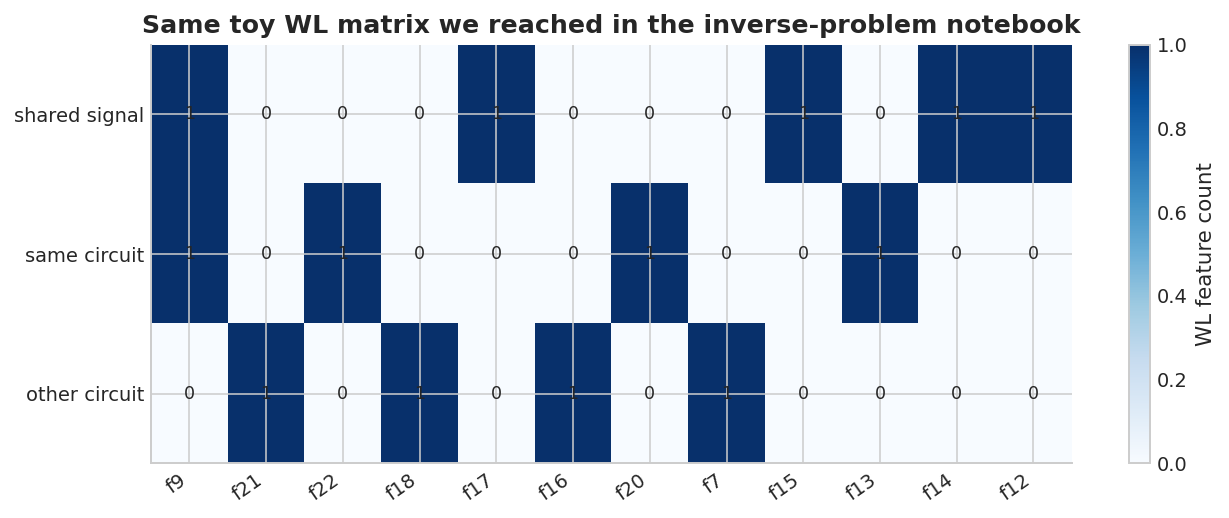

In [2]:
node_labels = ["L0T0", "L0T1", "L1T0", "L1T1"]
component_axis = [ComponentSpec(node_type="res")]

def make_dataset(matrix, slice_label):
    ds = PatchEffectDataset()
    for i in range(matrix.shape[0]):
        pair = PromptPair(
            x_cln=f"clean-{slice_label.corruption}-{i}",
            x_crp=f"corrupt-{slice_label.corruption}-{i}",
            y_star="target",
            slice_label=slice_label,
            meta={},
        )
        effects = matrix[i].reshape(2, 2, 1).astype(np.float32)
        ds.add(
            PatchEffectTensor(
                effects=effects,
                component_axis=component_axis,
                prompt_pair=pair,
                base_score=-1.0,
                clean_score=1.0,
            )
        )
    return ds

X_obs = np.array([
    [ 2.0,  1.8, -1.6,  0.1],
    [ 1.0,  0.9, -0.8, -0.1],
    [ 0.0,  0.1,  0.0,  0.2],
    [-1.0, -0.8,  0.7,  0.0],
    [-2.0, -1.7,  1.5, -0.2],
    [-1.0, -0.9,  0.8,  0.1],
], dtype=np.float32)

X_same_circuit = np.array([
    [ 1.8,  1.6, -1.5,  0.1],
    [ 0.9,  0.8, -0.8,  0.0],
    [ 0.1,  0.0, -0.1,  0.1],
    [-0.9, -0.8,  0.7,  0.0],
    [-1.8, -1.6,  1.4, -0.1],
    [-0.9, -0.8,  0.7,  0.1],
], dtype=np.float32)

X_other_circuit = np.array([
    [ 1.8,  0.1, -0.2,  1.6],
    [ 0.9,  0.0, -0.1,  0.8],
    [ 0.0,  0.1,  0.0,  0.1],
    [-0.9,  0.1,  0.2, -0.8],
    [-1.8, -0.1,  0.2, -1.6],
    [-0.9,  0.0,  0.1, -0.8],
], dtype=np.float32)

slice_obs = SliceLabel(task="inverse_demo", corruption="shared_signal")
slice_same = SliceLabel(task="inverse_demo", corruption="same_circuit")
slice_other = SliceLabel(task="inverse_demo", corruption="other_circuit")

builder = GraphBuilder(k=2, enforce_direction=True)
graph_obs = builder.build_from_slice(make_dataset(X_obs, slice_obs), slice_obs)
graph_same = builder.build_from_slice(make_dataset(X_same_circuit, slice_same), slice_same)
graph_other = builder.build_from_slice(make_dataset(X_other_circuit, slice_other), slice_other)

graphs = {
    slice_obs: graph_obs,
    slice_same: graph_same,
    slice_other: graph_other,
}
feature_matrix = compute_wl_features(graphs, depth=2)
X_wl = feature_matrix.to_matrix()
slice_names = [s.corruption for s in feature_matrix.slice_labels]
pretty_slice_names = [name.replace("_", " ") for name in slice_names]

feature_var = X_wl.var(axis=0)
active_idx = [idx for idx in np.argsort(feature_var)[::-1] if feature_var[idx] > 0][:12]
if not active_idx:
    active_idx = list(range(min(12, X_wl.shape[1])))
X_wl_view = X_wl[:, active_idx]
feature_labels = [f"f{idx}" for idx in active_idx]

print("WL matrix shape:", X_wl.shape)
print("Slice order:", slice_names)

fig, ax = plt.subplots(figsize=(9.5, 3.8))
im = ax.imshow(X_wl_view, aspect="auto", cmap="Blues")
ax.set_xticks(np.arange(len(feature_labels)))
ax.set_xticklabels(feature_labels, rotation=35, ha="right")
ax.set_yticks(np.arange(len(slice_names)))
ax.set_yticklabels(pretty_slice_names)
ax.set_title("Same toy WL matrix we reached in the inverse-problem notebook")
for i in range(X_wl_view.shape[0]):
    for j in range(X_wl_view.shape[1]):
        ax.text(j, i, f"{int(X_wl_view[i, j])}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="WL feature count")
plt.tight_layout()
plt.show()


## Stage 2. Verify the bridge with the old similarity view

In the previous notebook, the final view was a **cosine similarity** over WL features.

We start by reproducing that same lens, so the handoff between notebooks is explicit.


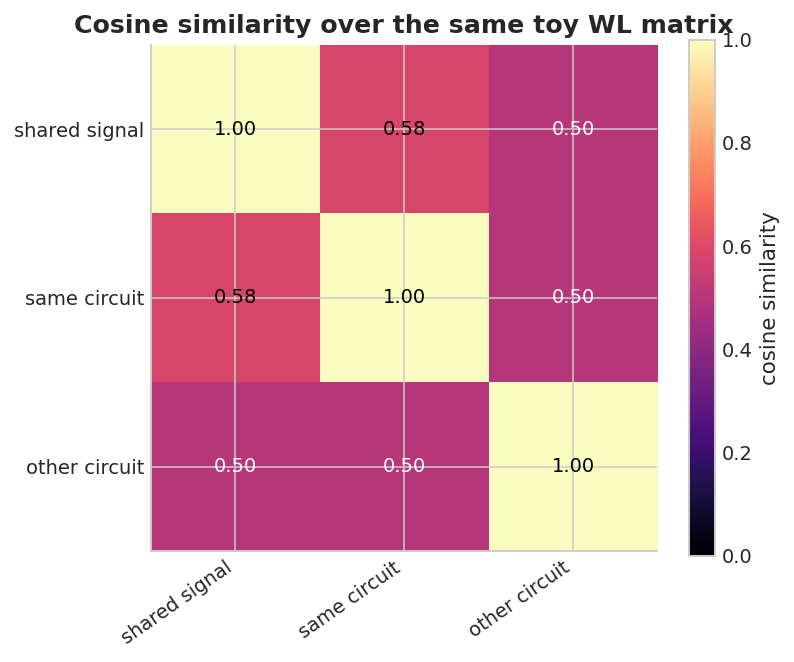

Pairwise cosine similarities
  shared_signal vs shared_signal: 1.000
  shared_signal vs same_circuit : 0.583
  shared_signal vs other_circuit: 0.500
   same_circuit vs shared_signal: 0.583
   same_circuit vs same_circuit : 1.000
   same_circuit vs other_circuit: 0.500
  other_circuit vs shared_signal: 0.500
  other_circuit vs same_circuit : 0.500
  other_circuit vs other_circuit: 1.000


In [3]:
K_cosine = cosine_similarity(X_wl)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(K_cosine, cmap="magma", vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(slice_names)))
ax.set_xticklabels(pretty_slice_names, rotation=35, ha="right")
ax.set_yticks(np.arange(len(slice_names)))
ax.set_yticklabels(pretty_slice_names)
ax.set_title("Cosine similarity over the same toy WL matrix")
for i in range(K_cosine.shape[0]):
    for j in range(K_cosine.shape[1]):
        ax.text(j, i, f"{K_cosine[i, j]:.2f}", ha="center", va="center", fontsize=10, color="white" if K_cosine[i, j] < 0.55 else "black")
plt.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.show()

print("Pairwise cosine similarities")
for i, a in enumerate(slice_names):
    for j, b in enumerate(slice_names):
        print(f"  {a:>13} vs {b:<13}: {K_cosine[i, j]:.3f}")


## Stage 3. What changes when we move from cosine to the actual classical kernels

The repo's classical kernel path does not use cosine similarity as the classifier itself.

It uses:

- `StandardScaler`
- `SVC(kernel="linear")` or `SVC(kernel="rbf")`

So the next step is to take this same WL matrix and look at the similarities induced by those kernels.


### Why do we apply `StandardScaler`?

This is one of the most important design choices in the real pipeline.

The reason is geometric:

- the **linear kernel** uses dot products,
- the **RBF kernel** uses Euclidean distances,
- and both are sensitive to feature scale.

If one WL feature has a much larger numeric range than the others, it can dominate the similarity computation even if it is not the most informative feature structurally.

So in the real pipeline we standardize feature-by-feature:

$$
x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

where:

- $x_{ij}$ is the original value of feature $j$ in slice $i$,
- $\mu_j$ is the mean of feature $j$,
- $\sigma_j$ is the standard deviation of feature $j$.

In other words, each column is re-centered and re-scaled so that no single WL feature wins just because of its raw numeric scale.


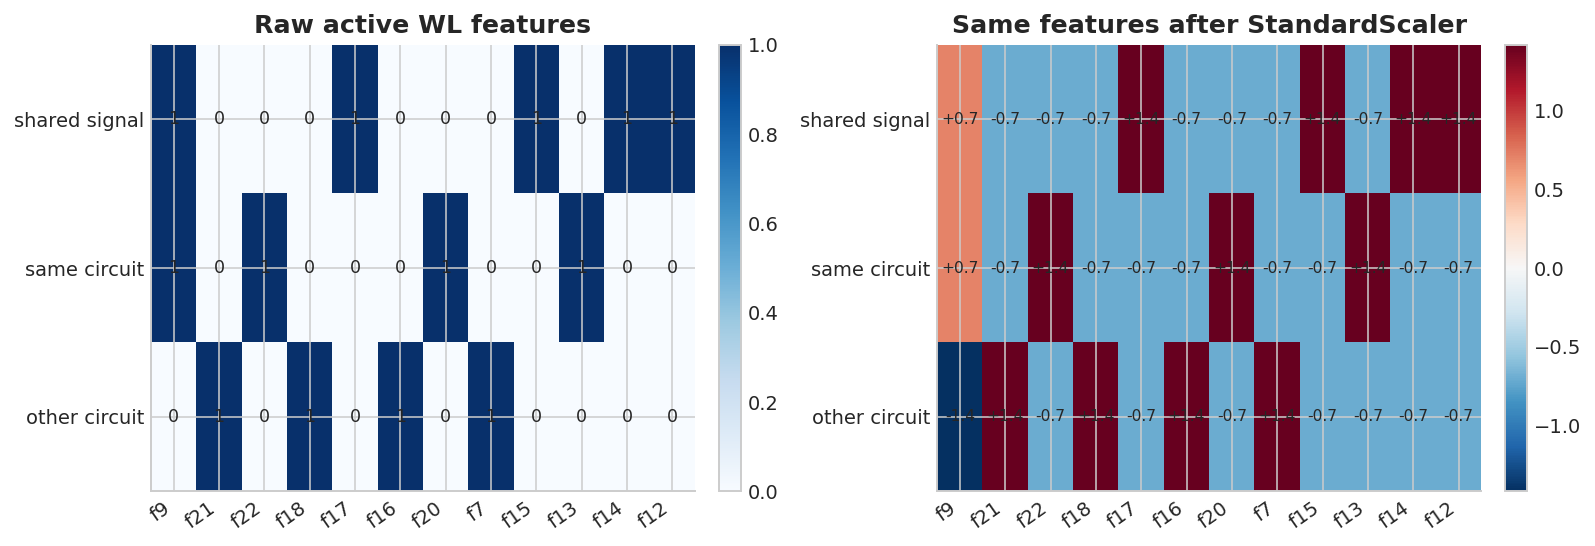

In [4]:
scaler = StandardScaler()
X_wl_scaled = scaler.fit_transform(X_wl)

scaled_view = X_wl_scaled[:, active_idx]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
im0 = axes[0].imshow(X_wl_view, aspect="auto", cmap="Blues")
axes[0].set_title("Raw active WL features")
axes[0].set_xticks(np.arange(len(feature_labels)))
axes[0].set_xticklabels(feature_labels, rotation=35, ha="right")
axes[0].set_yticks(np.arange(len(slice_names)))
axes[0].set_yticklabels(pretty_slice_names)
for i in range(X_wl_view.shape[0]):
    for j in range(X_wl_view.shape[1]):
        axes[0].text(j, i, f"{int(X_wl_view[i, j])}", ha="center", va="center", fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax = float(np.max(np.abs(scaled_view)))
im1 = axes[1].imshow(scaled_view, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("Same features after StandardScaler")
axes[1].set_xticks(np.arange(len(feature_labels)))
axes[1].set_xticklabels(feature_labels, rotation=35, ha="right")
axes[1].set_yticks(np.arange(len(slice_names)))
axes[1].set_yticklabels(pretty_slice_names)
for i in range(scaled_view.shape[0]):
    for j in range(scaled_view.shape[1]):
        axes[1].text(j, i, f"{scaled_view[i, j]:+.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### What can we see in the scaling figure?

- The **left panel** is the actual WL feature block the kernel receives.
- The **right panel** is the same block after standardization.

What changes:

- raw counts like `0` and `1` become positive or negative z-scores,
- a positive number now means “this slice has more of this feature than average,”
- a negative number means “this slice has less of this feature than average.”

So after scaling, the kernel is no longer comparing raw counts directly.
It is comparing each slice in terms of **relative over-expression or under-expression of structural patterns**.


## Stage 4. Linear kernel on the inverse-problem WL matrix

The linear kernel is just a dot product between scaled WL rows:

$$
K_{\text{linear}}(x_i, x_j) = x_i^\top x_j
$$

So it measures whether two slices point in a similar direction in WL feature space.


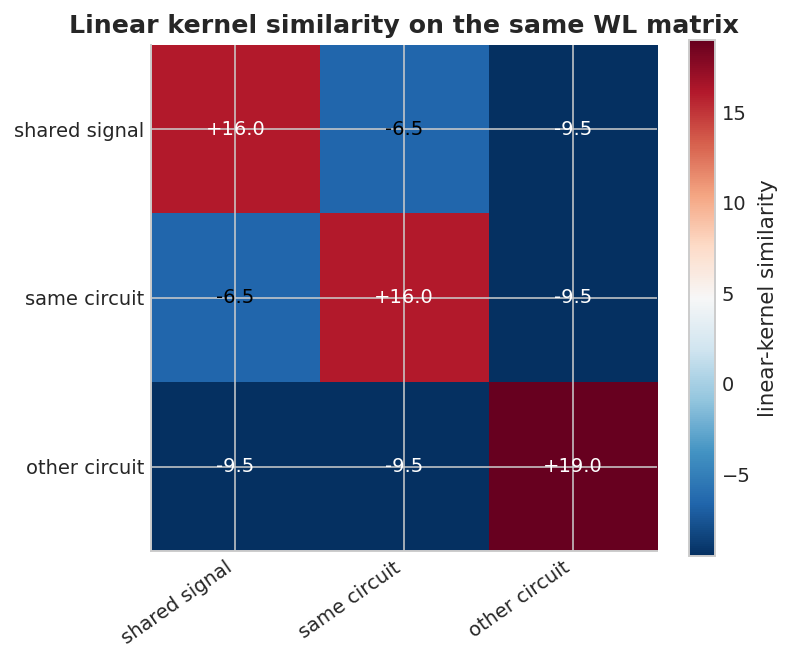

Linear-kernel similarities
  shared_signal vs shared_signal: +16.000
  shared_signal vs same_circuit : -6.500
  shared_signal vs other_circuit: -9.500
   same_circuit vs shared_signal: -6.500
   same_circuit vs same_circuit : +16.000
   same_circuit vs other_circuit: -9.500
  other_circuit vs shared_signal: -9.500
  other_circuit vs same_circuit : -9.500
  other_circuit vs other_circuit: +19.000


In [5]:
K_linear = linear_kernel(X_wl_scaled, X_wl_scaled)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(K_linear, cmap="RdBu_r")
ax.set_xticks(np.arange(len(slice_names)))
ax.set_xticklabels(pretty_slice_names, rotation=35, ha="right")
ax.set_yticks(np.arange(len(slice_names)))
ax.set_yticklabels(pretty_slice_names)
ax.set_title("Linear kernel similarity on the same WL matrix")
for i in range(K_linear.shape[0]):
    for j in range(K_linear.shape[1]):
        ax.text(j, i, f"{K_linear[i, j]:+.1f}", ha="center", va="center", fontsize=10, color="white" if abs(K_linear[i, j]) > 7 else "black")
plt.colorbar(im, ax=ax, label="linear-kernel similarity")
plt.tight_layout()
plt.show()

print("Linear-kernel similarities")
for i, a in enumerate(slice_names):
    for j, b in enumerate(slice_names):
        print(f"  {a:>13} vs {b:<13}: {K_linear[i, j]:+.3f}")


### How to read the linear-kernel heatmap

In this matrix:

- a **large positive** value means two slices activate similar standardized WL patterns,
- a **negative** value means their WL patterns point in opposite directions,
- the diagonal is large because each slice is perfectly similar to itself.

So the main question is not whether values are big in absolute terms, but whether the **relative structure** matches the story we expect.

Here you can already see that `shared_signal` and `same_circuit` are closer to each other than either is to `other_circuit`.


## Stage 5. RBF kernel on the same WL matrix

The RBF kernel uses distance:

$$
K_{\text{RBF}}(x_i, x_j) = \exp\left(-\gamma \lVert x_i - x_j \rVert^2\right)
$$

This makes the notion of similarity more local. Two slices only look similar if their WL rows are truly close.


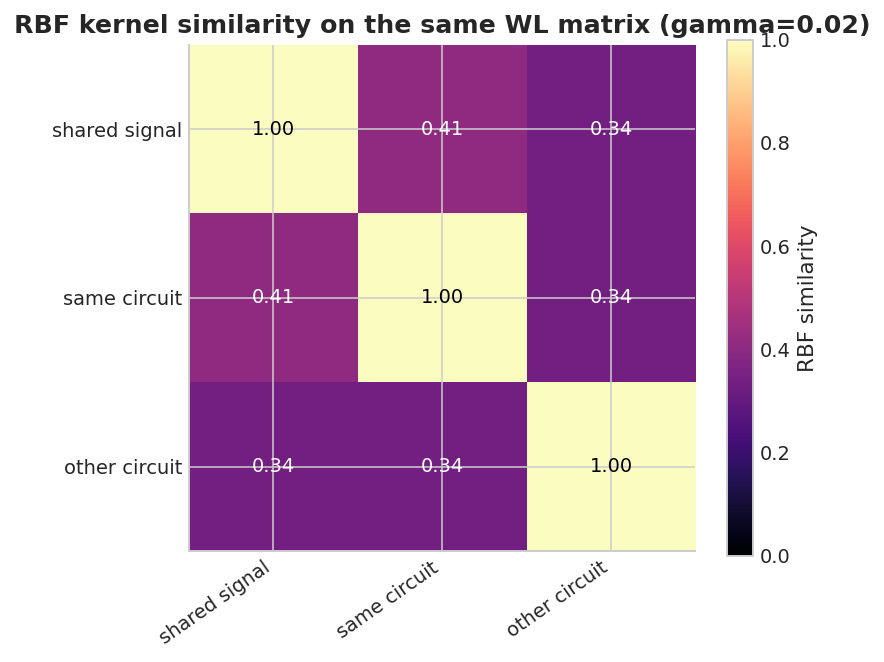

RBF-kernel similarities
  shared_signal vs shared_signal: 1.000
  shared_signal vs same_circuit : 0.407
  shared_signal vs other_circuit: 0.340
   same_circuit vs shared_signal: 0.407
   same_circuit vs same_circuit : 1.000
   same_circuit vs other_circuit: 0.340
  other_circuit vs shared_signal: 0.340
  other_circuit vs same_circuit : 0.340
  other_circuit vs other_circuit: 1.000


In [6]:
gamma = 0.02
K_rbf = rbf_kernel(X_wl_scaled, X_wl_scaled, gamma=gamma)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(K_rbf, cmap="magma", vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(slice_names)))
ax.set_xticklabels(pretty_slice_names, rotation=35, ha="right")
ax.set_yticks(np.arange(len(slice_names)))
ax.set_yticklabels(pretty_slice_names)
ax.set_title(f"RBF kernel similarity on the same WL matrix (gamma={gamma})")
for i in range(K_rbf.shape[0]):
    for j in range(K_rbf.shape[1]):
        ax.text(j, i, f"{K_rbf[i, j]:.2f}", ha="center", va="center", fontsize=10, color="white" if K_rbf[i, j] < 0.55 else "black")
plt.colorbar(im, ax=ax, label="RBF similarity")
plt.tight_layout()
plt.show()

print("RBF-kernel similarities")
for i, a in enumerate(slice_names):
    for j, b in enumerate(slice_names):
        print(f"  {a:>13} vs {b:<13}: {K_rbf[i, j]:.3f}")


### How to read the RBF heatmap

The RBF kernel turns distances into similarities between `0` and `1`.

That means:

- `1.00` means “identical to itself,”
- values closer to `1` mean “very close in WL space,”
- values closer to `0` mean “far apart.”

Compared with the linear kernel, the RBF kernel gives a more **local** notion of similarity.
It is less about overall direction and more about neighborhood closeness.


## Stage 6. The same three slices, now seen through three similarity lenses

This is the cleanest way to relate the notebooks:

- the inverse-problem notebook ends with the **cosine** view,
- this notebook shows what the **linear** and **RBF** kernel views do to the same rows.


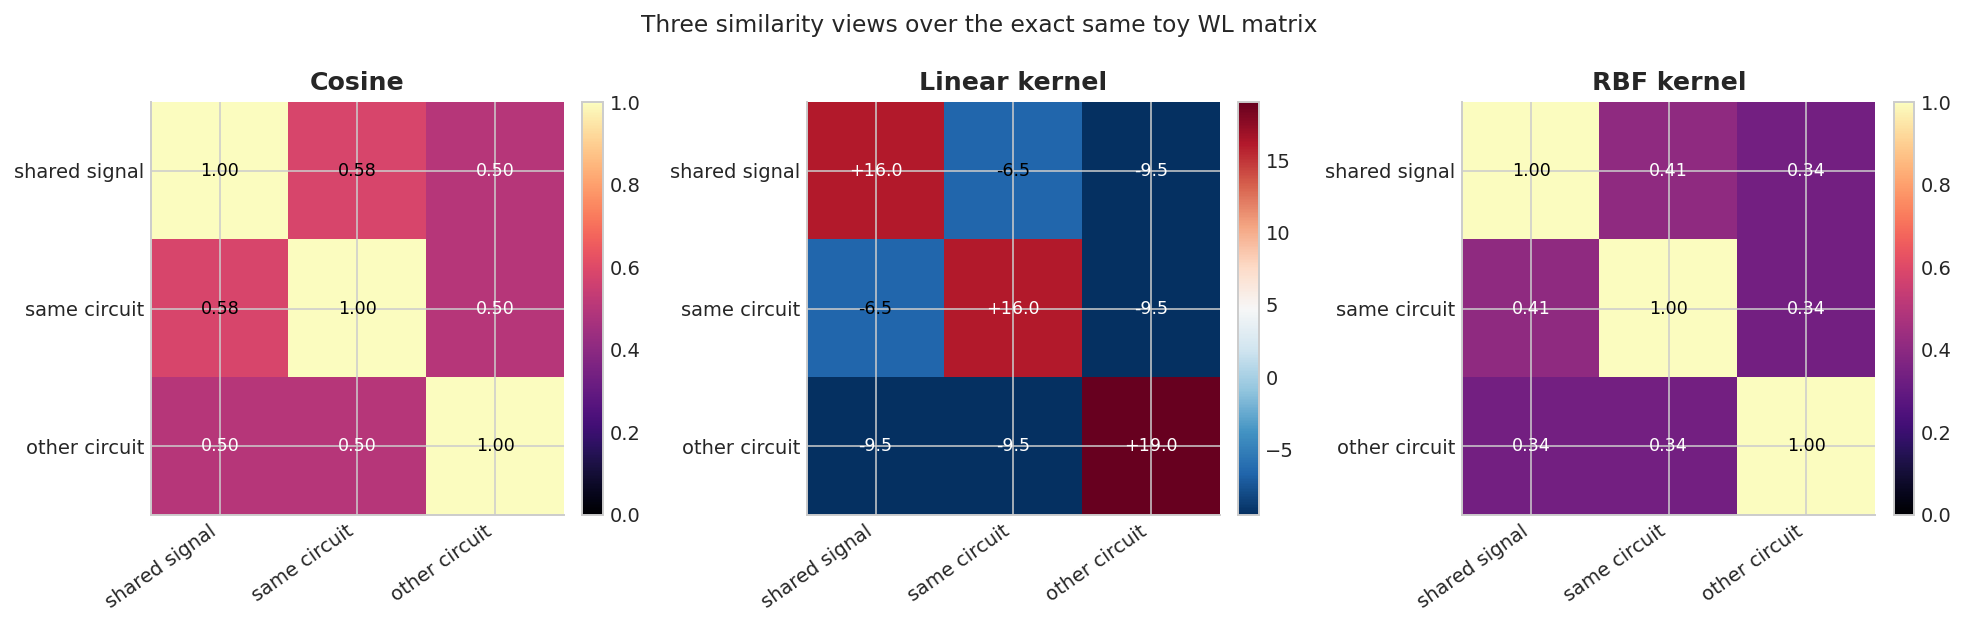

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.2))
for ax, K, title, cmap, vmin, vmax in [
    (axes[0], K_cosine, "Cosine", "magma", 0.0, 1.0),
    (axes[1], K_linear, "Linear kernel", "RdBu_r", None, None),
    (axes[2], K_rbf, "RBF kernel", "magma", 0.0, 1.0),
]:
    im = ax.imshow(K, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(slice_names)))
    ax.set_xticklabels(pretty_slice_names, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(slice_names)))
    ax.set_yticklabels(pretty_slice_names)
    ax.set_title(title)
    for i in range(K.shape[0]):
        for j in range(K.shape[1]):
            label = f"{K[i, j]:+.1f}" if title == "Linear kernel" else f"{K[i, j]:.2f}"
            color = "white" if (title == "Linear kernel" and abs(K[i, j]) > 7) or (title != "Linear kernel" and K[i, j] < 0.55) else "black"
            ax.text(j, i, label, ha="center", va="center", fontsize=9, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Three similarity views over the exact same toy WL matrix", y=1.02)
plt.tight_layout()
plt.show()


### Reality check: this comparison is the real kernel story

Up to this point, everything is already faithful to the real classical pipeline:

1. start from a WL matrix,
2. scale it,
3. compute similarities induced by the kernel.

This is the core reality.

The next section with PCA is **not** the real classifier space.
It is only a 2D picture that helps us look at a decision boundary with human eyes.


## Stage 7. What the real classifier actually does

In the actual pipeline, we do **not** project to 2D first.

The real flow is:

- take the full WL matrix,
- fit a `StandardScaler`,
- fit an `SVC(kernel="linear")` or `SVC(kernel="rbf")`,
- evaluate with cross-validation.

So before any PCA picture, we expose the actual estimator object used by the repo.


In [8]:
real_linear_clf = ClassicalKernelClassifier(kernel="linear", random_state=42, normalize=True)
real_rbf_clf = ClassicalKernelClassifier(kernel="rbf", random_state=42, normalize=True)

print("Actual estimator used for CV (linear):")
print(real_linear_clf._create_cv_estimator())
print()
print("Actual estimator used for CV (rbf):")
print(real_rbf_clf._create_cv_estimator())


Actual estimator used for CV (linear):
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(kernel='linear', probability=True, random_state=42))])

Actual estimator used for CV (rbf):
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])


## Stage 8. Build a tiny training cloud around the real WL anchors

The real pipeline trains on many WL rows, not just three.

So we create a small toy training set that stays faithful to the previous notebook:

- keep the exact three WL rows from the inverse-problem notebook as **anchors**,
- generate small perturbation copies around them,
- and assign labels so that:
  - **reuse-family** = perturbations around `shared_signal` and `same_circuit`
  - **other-family** = perturbations around `other_circuit`

This is still a toy setup, but it lets us fit the exact classifier used by the pipeline and then probe what it does in the **original WL space**.


In [9]:
anchor_lookup = {name: X_wl[idx] for idx, name in enumerate(slice_names)}

augment_specs = [
    ("shared_signal", 0, 4, 0.22),
    ("same_circuit", 0, 4, 0.22),
    ("other_circuit", 1, 5, 0.22),
]

X_aug = []
y_aug = []
point_names = []
for anchor_name, label, copies, noise_scale in augment_specs:
    anchor = anchor_lookup[anchor_name]
    for copy_idx in range(copies):
        noise = rng.normal(scale=noise_scale, size=anchor.shape)
        X_aug.append(anchor + noise)
        y_aug.append(label)
        point_names.append(f"{anchor_name[:2]}-{copy_idx+1}")

X_aug = np.asarray(X_aug, dtype=np.float32)
y_aug = np.asarray(y_aug, dtype=np.int32)
class_names = {0: "reuse-family", 1: "other-family"}

print("Augmented WL matrix shape:", X_aug.shape)
print("Class balance:", {class_names[int(k)]: int((y_aug == k).sum()) for k in np.unique(y_aug)})


Augmented WL matrix shape: (13, 23)
Class balance: {'reuse-family': 8, 'other-family': 5}


## Stage 9. Probe the real classifier in the original WL space

Instead of projecting to PCA, we now inspect the classifier in the real feature space.

We use two exact formulas:

Linear SVM decision:

$$
f_{\mathrm{linear}}(x) = w^\top x + b
$$

Kernel SVM decision:

$$
f_{\mathrm{kernel}}(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b
$$

where:

- $x$ is the WL row being evaluated,
- $x_i$ are training WL rows,
- $y_i$ are class labels,
- $\alpha_i$ are the learned support-vector weights,
- $K(\cdot, \cdot)$ is the kernel function.

To make this visible, we take exact interpolation paths in the original WL space:

$$
x(t) = (1 - t) x_a + t x_b, \qquad t \in [0, 1]
$$

and evaluate:

- kernel similarity to the anchor rows,
- and the actual SVM decision score along the path.


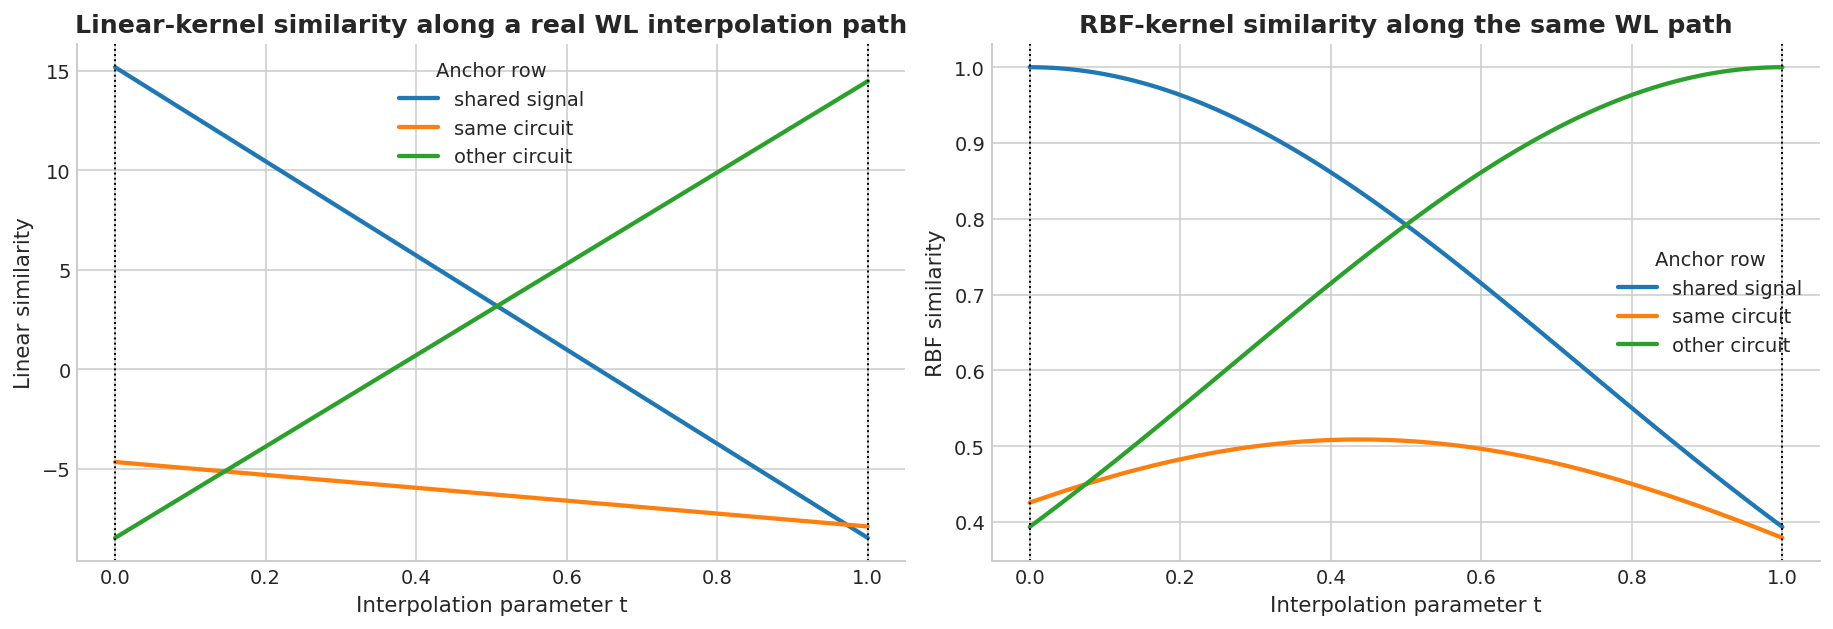

In [10]:
scaler_aug = StandardScaler()
X_aug_scaled = scaler_aug.fit_transform(X_aug)
X_anchor_scaled = scaler_aug.transform(X_wl)

linear_vis = SVC(kernel="linear", C=1.0)
rbf_vis = SVC(kernel="rbf", C=1.0, gamma=0.02)
linear_vis.fit(X_aug_scaled, y_aug)
rbf_vis.fit(X_aug_scaled, y_aug)

t = np.linspace(0.0, 1.0, 101)
path_start = anchor_lookup["shared_signal"]
path_end = anchor_lookup["other_circuit"]
path_points = np.stack([(1.0 - s) * path_start + s * path_end for s in t], axis=0)
path_scaled = scaler_aug.transform(path_points)

linear_to_anchors = linear_kernel(path_scaled, X_anchor_scaled)
rbf_to_anchors = rbf_kernel(path_scaled, X_anchor_scaled, gamma=0.02)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))
for idx, name in enumerate(pretty_slice_names):
    axes[0].plot(t, linear_to_anchors[:, idx], linewidth=2.2, label=name)
    axes[1].plot(t, rbf_to_anchors[:, idx], linewidth=2.2, label=name)

axes[0].set_title("Linear-kernel similarity along a real WL interpolation path")
axes[0].set_xlabel("Interpolation parameter t")
axes[0].set_ylabel("Linear similarity")

axes[1].set_title("RBF-kernel similarity along the same WL path")
axes[1].set_xlabel("Interpolation parameter t")
axes[1].set_ylabel("RBF similarity")

for ax in axes:
    ax.axvline(0.0, color="black", linestyle=":", linewidth=1.0)
    ax.axvline(1.0, color="black", linestyle=":", linewidth=1.0)
    ax.legend(title="Anchor row", loc="best")

plt.tight_layout()
plt.show()


### How to read the interpolation-similarity plots

These two panels are now showing the **real feature space**, not a projection.

The horizontal axis is the interpolation parameter $t$:

- $t = 0$ is exactly the `shared_signal` WL row,
- $t = 1$ is exactly the `other_circuit` WL row,
- values in between are convex mixtures of those two original WL rows.

The legend tells you **which anchor row** we are measuring similarity to.

So, for example, in the left plot:

- the `shared_signal` curve starts highest at $t=0$ because the path begins there,
- the `other_circuit` curve ends highest at $t=1$ because the path finishes there,
- the `same_circuit` curve tells you whether the path passes through regions that still look structurally similar to that second reuse-style anchor.

The difference between the panels is the metric:

- the **linear panel** reflects signed dot-product similarity after scaling,
- the **RBF panel** reflects local closeness in Euclidean distance.

So these plots are the cleanest “real” picture of what the kernels are doing to a WL row as it moves through feature space.


## Stage 10. Exact SVM decision score along real WL-space paths

The next plot evaluates the actual fitted SVM decision function on two original-space trajectories:

- `shared_signal` $\rightarrow$ `other_circuit`
- `same_circuit` $\rightarrow$ `other_circuit`

Interpretation of the decision score:

- **positive** score: classifier prefers `other-family`,
- **negative** score: classifier prefers `reuse-family`,
- **zero crossing**: decision boundary.

This is more faithful than PCA because the classifier is being queried on actual WL-space points.


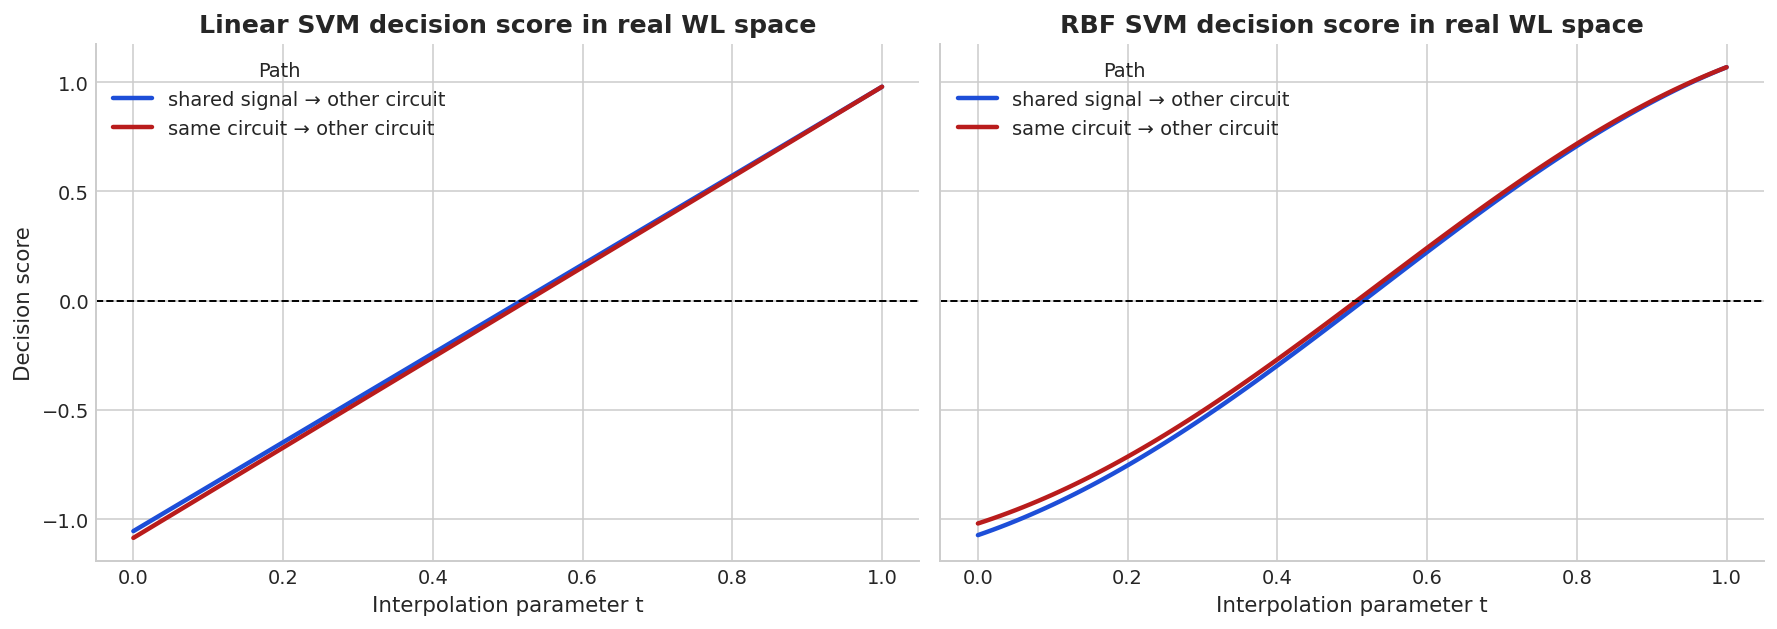

In [11]:
path_specs = [
    ("shared_signal", "other_circuit", "#1d4ed8"),
    ("same_circuit", "other_circuit", "#b91c1c"),
]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), sharey=True)

for start_name, end_name, color in path_specs:
    start = anchor_lookup[start_name]
    end = anchor_lookup[end_name]
    points = np.stack([(1.0 - s) * start + s * end for s in t], axis=0)
    points_scaled = scaler_aug.transform(points)

    linear_scores = linear_vis.decision_function(points_scaled)
    rbf_scores = rbf_vis.decision_function(points_scaled)

    label = f"{start_name.replace('_', ' ')} → {end_name.replace('_', ' ')}"
    axes[0].plot(t, linear_scores, color=color, linewidth=2.3, label=label)
    axes[1].plot(t, rbf_scores, color=color, linewidth=2.3, label=label)

axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)

axes[0].set_title("Linear SVM decision score in real WL space")
axes[0].set_xlabel("Interpolation parameter t")
axes[0].set_ylabel("Decision score")
axes[0].legend(title="Path", loc="best")

axes[1].set_title("RBF SVM decision score in real WL space")
axes[1].set_xlabel("Interpolation parameter t")
axes[1].legend(title="Path", loc="best")

plt.tight_layout()
plt.show()


### How to read the decision-score plots

Each colored line is one interpolation path between two real anchor WL rows.

The legend tells you which path you are looking at.

The dashed horizontal line at `0` is the classifier boundary:

- below `0`: the point is classified as `reuse-family`,
- above `0`: the point is classified as `other-family`.

What you should look for:

- where the line crosses `0`,
- how abruptly it crosses,
- and whether the linear and RBF classifiers transition at similar places.

If the RBF curve bends differently from the linear curve, that means the nonlinear kernel is carving out a different local notion of similarity, even though both are operating on the same underlying WL vectors.


## Stage 11. Use the same classifier object as the repo

Finally, we run the actual `ClassicalKernelClassifier` object on the augmented WL cloud.

That closes the loop:

- the **anchor rows** come from the inverse-problem notebook,
- the **geometry** comes from small perturbations around those rows,
- and the **classifier** is the same object used by the repo's classical baseline.


In [12]:
linear_clf = ClassicalKernelClassifier(kernel="linear", random_state=42, normalize=True)
rbf_clf = ClassicalKernelClassifier(kernel="rbf", random_state=42, normalize=True)

linear_cv = linear_clf.cross_validate(X_aug, y_aug, cv=4)
rbf_cv = rbf_clf.cross_validate(X_aug, y_aug, cv=4)

print("Linear CV:", linear_cv)
print("RBF CV:", rbf_cv)


Linear CV: {'accuracy_mean': 1.0, 'accuracy_std': 0.0, 'kernel_type': 'linear', 'cv_folds': 4}
RBF CV: {'accuracy_mean': 1.0, 'accuracy_std': 0.0, 'kernel_type': 'rbf', 'cv_folds': 4}


### What should we conclude from the CV result?

The exact score here is not the main point, because the setup is still toy.

What matters is that:

- the same classifier object used by the repo can separate these anchored WL patterns,
- both kernels operate directly on full WL rows,
- and the notebook has shown the **real mechanism** directly in WL space.


## Stage 12. Tiny real-pipeline check on actual repo data

Up to this point, the notebook has used the exact toy WL anchors from the inverse-problem walkthrough.

To show that the same kernel block also works on a genuine pipeline output, we now run a **small real check** with the in-repo `toy_transformer`:

1. generate real IOI prompt pairs,
2. compute real patch effects,
3. build real per-example graphs,
4. compute a real WL feature matrix,
5. and run the same classical kernel baselines on it.

This section is intentionally small and fast.
The goal is not to benchmark the model; the goal is to show that the exact same kernel logic survives contact with real pipeline artifacts.


### Why use per-example graphs here?

The classical classifier needs multiple rows to run cross-validation.

A canonical slice graph gives one graph per corruption slice, which is ideal for structural interpretation but too small for a useful classifier demo.

So for this final reality check we use the repo's **per-example graph baseline**, which gives one graph per prompt pair and therefore enough WL rows to train and validate the kernel classifier.


Real WL matrix shape: (8, 365)
Real labels: ['name swap 1', 'name swap 2', 'name swap 3', 'name swap 4', 'abba 1', 'abba 2', 'abba 3', 'abba 4']


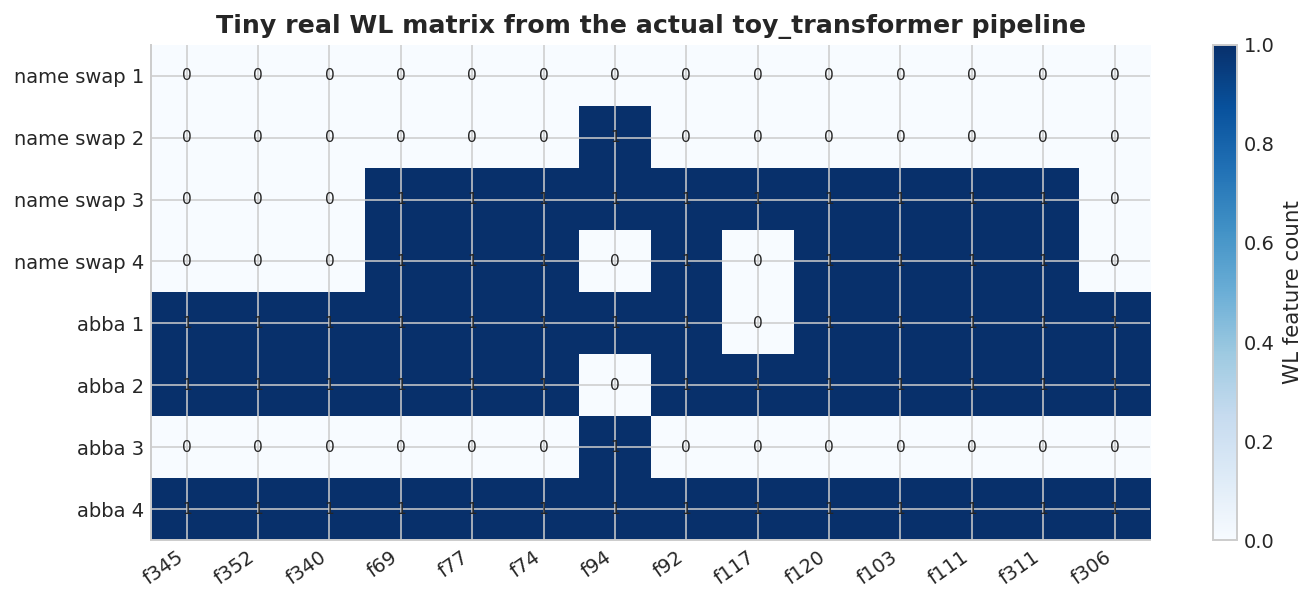

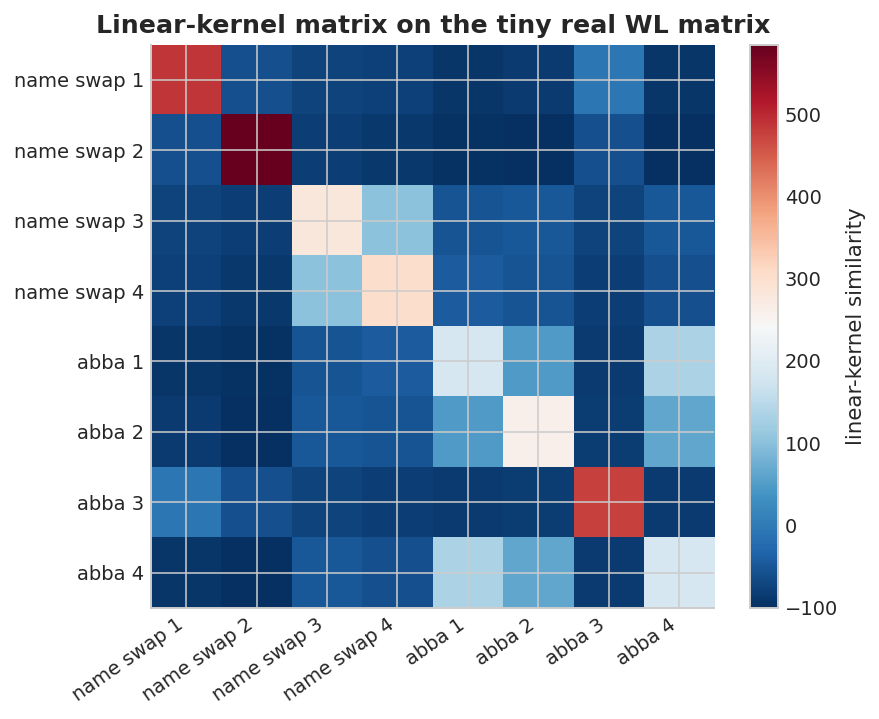

Tiny real-check CV (linear): {'accuracy_mean': 0.75, 'accuracy_std': 0.25, 'kernel_type': 'linear', 'cv_folds': 4}
Tiny real-check CV (rbf): {'accuracy_mean': 0.75, 'accuracy_std': 0.25, 'kernel_type': 'rbf', 'cv_folds': 4}


In [13]:
real_prompt_pairs = []
for offset, corruption in enumerate(["name_swap", "abba"]):
    real_prompt_pairs.extend(
        create_ioi_dataset(
            n_examples=4,
            corruption=corruption,
            seed=7 + offset * 10_000,
        )
    )

real_model = create_model("toy_transformer", device="cpu")
real_dataset = compute_patch_effects(
    real_model,
    real_prompt_pairs,
    show_progress=False,
    node_types=["res"],
)

real_builder = create_graph_builder(
    "correlation_topk",
    k=3,
    enforce_direction=True,
)
real_example_graphs = real_builder.build_per_example(real_dataset)
real_feature_matrix = compute_wl_features_from_list(real_example_graphs, depth=3)

X_real = real_feature_matrix.to_matrix()
y_real = np.array([str(label) for label in real_feature_matrix.slice_labels])
family_counts = {}
pretty_y_real = []
for label in y_real:
    family = label.replace("ioi:", "").replace("_", " ")
    family_counts[family] = family_counts.get(family, 0) + 1
    pretty_y_real.append(f"{family} {family_counts[family]}")

real_var = X_real.var(axis=0)
real_active_idx = [idx for idx in np.argsort(real_var)[::-1] if real_var[idx] > 0][:14]
X_real_view = X_real[:, real_active_idx]
real_feature_labels = [f"f{idx}" for idx in real_active_idx]

print("Real WL matrix shape:", X_real.shape)
print("Real labels:", pretty_y_real)

fig, ax = plt.subplots(figsize=(10.2, 4.4))
im = ax.imshow(X_real_view, aspect="auto", cmap="Blues")
ax.set_xticks(np.arange(len(real_feature_labels)))
ax.set_xticklabels(real_feature_labels, rotation=35, ha="right")
ax.set_yticks(np.arange(len(pretty_y_real)))
ax.set_yticklabels(pretty_y_real)
ax.set_title("Tiny real WL matrix from the actual toy_transformer pipeline")
for i in range(X_real_view.shape[0]):
    for j in range(X_real_view.shape[1]):
        ax.text(j, i, f"{int(X_real_view[i, j])}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="WL feature count")
plt.tight_layout()
plt.show()

real_scaler = StandardScaler()
X_real_scaled = real_scaler.fit_transform(X_real)
K_real_linear = linear_kernel(X_real_scaled, X_real_scaled)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(K_real_linear, cmap="RdBu_r")
ax.set_xticks(np.arange(len(pretty_y_real)))
ax.set_xticklabels(pretty_y_real, rotation=35, ha="right")
ax.set_yticks(np.arange(len(pretty_y_real)))
ax.set_yticklabels(pretty_y_real)
ax.set_title("Linear-kernel matrix on the tiny real WL matrix")
plt.colorbar(im, ax=ax, label="linear-kernel similarity")
plt.tight_layout()
plt.show()

_, real_linear_cv = train_classical_baseline(
    real_feature_matrix,
    kernel="linear",
    random_state=7,
)
_, real_rbf_cv = train_classical_baseline(
    real_feature_matrix,
    kernel="rbf",
    random_state=7,
)

print("Tiny real-check CV (linear):", real_linear_cv)
print("Tiny real-check CV (rbf):", real_rbf_cv)


### How to read the tiny real-pipeline figures

In the first plot:

- each **row** is one real prompt-pair graph from the actual toy-transformer patching pipeline,
- each **column** is one active WL feature,
- the row labels tell you which corruption family that example belongs to.

So this is no longer a hand-made toy matrix. It is a real WL matrix produced by repo code.

In the second plot:

- each row/column is one real example,
- the color shows linear-kernel similarity after scaling,
- and block structure is what you want to see.

If examples from the same label tend to be more similar to each other than to the other label, the kernel has a usable signal to classify.


### What does “it works” mean in this final check?

For this notebook, “it works” does **not** mean “state-of-the-art accuracy”.

It means something more specific and more defensible:

- the repo can produce a real WL matrix from real patching outputs,
- the kernel can turn that matrix into a structured similarity matrix,
- and the same `ClassicalKernelClassifier` used by the pipeline achieves accuracy above chance on that tiny real example set.

So this final section is the bridge from:

- **mechanism understanding** in the toy walkthrough,
- to **actual repo behavior** on a small but genuine run.


## What this notebook demonstrates

Relative to `inverse_problem_walkthrough.ipynb`, the message is now:

1. the previous notebook gave us a toy WL matrix over slices,
2. this notebook reuses that exact WL matrix,
3. cosine, linear-kernel, and RBF-kernel views are three different similarity lenses over the same rows,
4. the classical kernel stage works by turning those structural similarities into a decision rule,
5. and a tiny real-pipeline check shows that the same mechanism produces usable classification signal on actual repo outputs.

So the kernel stage is not a separate mystery.
It is simply the **next layer of comparison** built on top of the toy WL representation from the inverse-problem notebook.
